
# GPU 架构与执行模型可视化

> 目标：通过可复现的 Python 图形，理解 NVIDIA GPU 的硬件层级（SM、CUDA Core、Warp Scheduler）与软件执行层级（Grid、Block、Warp、Thread）。

## 目录

1. GPU 整体结构：从 GPU 到 SM 到 CUDA Core
2. 执行层级：Grid → Block → Warp → Thread
3. Warp Scheduler 与 Latency Hiding
4. SIMT、Warp Divergence 与 Memory Coalescing
5. Occupancy 计算与交互式探索
6. 总结与自查清单

**运行环境**：本 Notebook 使用 `Note/lec6/.venv`（Python 3.11 + PyTorch + matplotlib + ipywidgets）。



## Part 1：GPU 整体结构

NVIDIA GPU 可以抽象为：

- **GPU**：整张显卡，包含多个 SM、DRAM、L2 Cache。
- **SM (Streaming Multiprocessor)**：计算核心单元，每个 SM 包含 Warp Scheduler、CUDA Cores、Register File、Shared Memory / L1。
- **CUDA Core (SP)**：执行单个 thread 的标量运算单元。

我们用 matplotlib 画一个简化版 GPU 架构图。


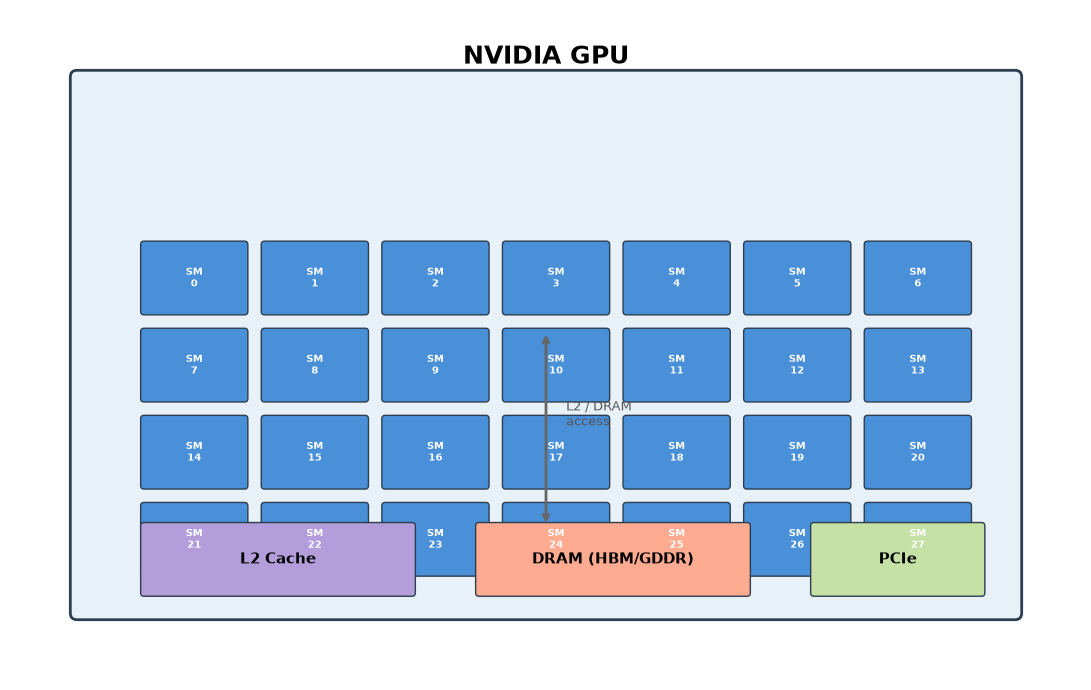

In [1]:

import matplotlib.pyplot as plt
import matplotlib.patches as patches


def draw_gpu_overview():
    fig, ax = plt.subplots(figsize=(12, 7))

    # GPU outer box
    gpu_rect = patches.FancyBboxPatch((1, 1), 14, 8, boxstyle="round,pad=0.1",
                                       facecolor="#e8f0f8", edgecolor="#2c3e50", linewidth=2)
    ax.add_patch(gpu_rect)
    ax.text(8, 9.2, "NVIDIA GPU", ha="center", fontsize=18, fontweight="bold")

    # SMs
    sm_rows, sm_cols = 4, 7
    for r in range(sm_rows):
        for c in range(sm_cols):
            x = 2 + c * 1.8
            y = 5.5 - r * 1.3
            rect = patches.FancyBboxPatch((x, y), 1.5, 1.0, boxstyle="round,pad=0.05",
                                          facecolor="#4a90d9", edgecolor="#2c3e50")
            ax.add_patch(rect)
            ax.text(x + 0.75, y + 0.5, "SM" + chr(10) + str(r*sm_cols+c), ha="center", va="center",
                    fontsize=7, color="white", fontweight="bold")

    # Memory components
    ax.add_patch(patches.FancyBboxPatch((2, 1.3), 4, 1.0, boxstyle="round,pad=0.05",
                                        facecolor="#b39ddb", edgecolor="#2c3e50"))
    ax.text(4, 1.8, "L2 Cache", ha="center", va="center", fontsize=11, fontweight="bold")

    ax.add_patch(patches.FancyBboxPatch((7, 1.3), 4, 1.0, boxstyle="round,pad=0.05",
                                        facecolor="#ffab91", edgecolor="#2c3e50"))
    ax.text(9, 1.8, "DRAM (HBM/GDDR)", ha="center", va="center", fontsize=11, fontweight="bold")

    ax.add_patch(patches.FancyBboxPatch((12, 1.3), 2.5, 1.0, boxstyle="round,pad=0.05",
                                        facecolor="#c5e1a5", edgecolor="#2c3e50"))
    ax.text(13.25, 1.8, "PCIe", ha="center", va="center", fontsize=11, fontweight="bold")

    # Arrows
    ax.annotate("", xy=(8, 2.3), xytext=(8, 5.2),
                arrowprops=dict(arrowstyle="<->", color="#666", lw=2))
    ax.text(8.3, 3.8, "L2 / DRAM" + chr(10) + "access", fontsize=9, color="#555")

    ax.set_xlim(0, 16)
    ax.set_ylim(0, 10)
    ax.set_aspect("equal")
    ax.axis("off")
    plt.tight_layout()
    plt.show()


draw_gpu_overview()



### 关键观察

1. **SM 是并行计算的基本单位**：一个 kernel 的 grid 会被划分成多个 block，block 再被分配到各个 SM。
2. **内存分层**：Register < L1/Shared Memory < L2 < DRAM。越靠近 SM 越快、越小。
3. **PCIe 是瓶颈**：CPU ↔ GPU 数据传输比 GPU 内部 DRAM 访问慢得多。



## Part 2：SM 内部结构

一个 SM 内部主要包含：

| 组件 | 作用 |
|------|------|
| Warp Scheduler | 选择 ready warp，派发指令 |
| Dispatch Unit | 把指令分发到具体执行单元 |
| CUDA Cores (FP32/INT) | 执行标量运算 |
| Tensor Cores | 加速矩阵乘/卷积 |
| SFU | 特殊函数（sin, cos, exp, rsqrt） |
| Load/Store Units | 内存读写 |
| Register File | 给活跃 thread 保存寄存器 |
| Shared Memory / L1 | 同 block threads 共享的快速存储 |


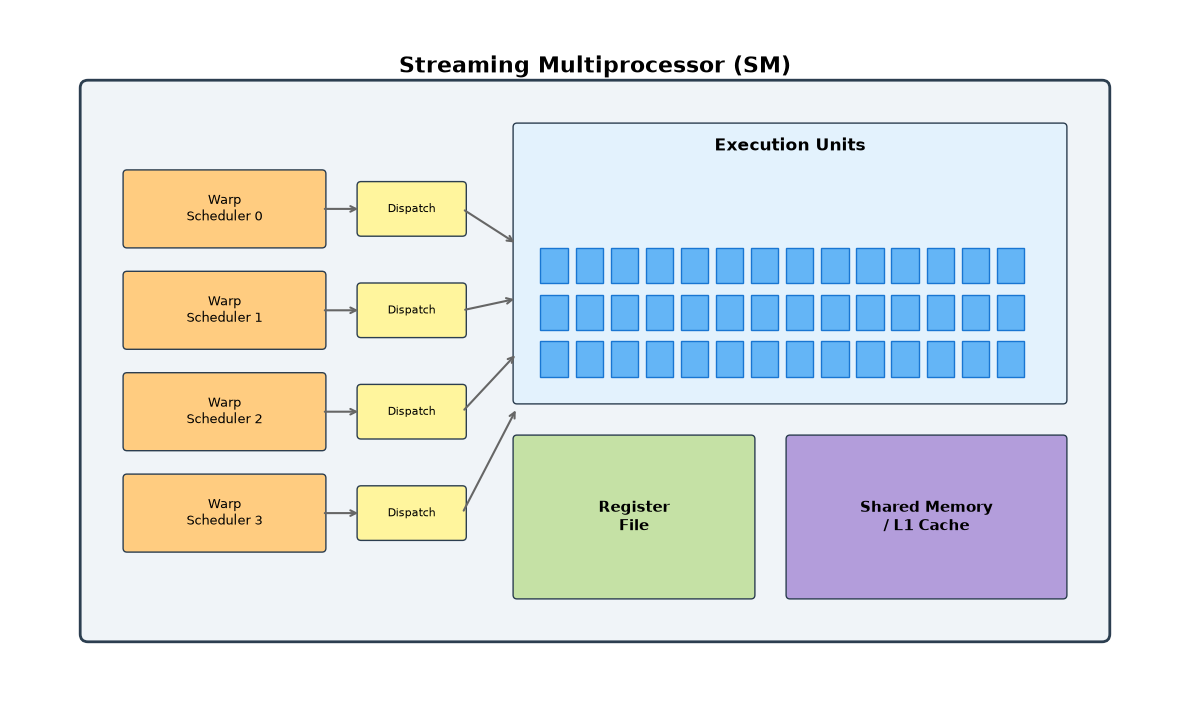

In [2]:

def draw_sm_internals():
    fig, ax = plt.subplots(figsize=(12, 8))

    # SM box
    sm_rect = patches.FancyBboxPatch((1, 1), 13, 7, boxstyle="round,pad=0.1",
                                      facecolor="#f0f4f8", edgecolor="#2c3e50", linewidth=2)
    ax.add_patch(sm_rect)
    ax.text(7.5, 8.2, "Streaming Multiprocessor (SM)", ha="center", fontsize=16, fontweight="bold")

    # Warp schedulers
    for i in range(4):
        y = 6.0 - i * 1.3
        ax.add_patch(patches.FancyBboxPatch((1.5, y), 2.5, 0.9, boxstyle="round,pad=0.05",
                                            facecolor="#ffcc80", edgecolor="#2c3e50"))
        ax.text(2.75, y + 0.45, f"Warp" + chr(10) + f"Scheduler {i}", ha="center", va="center", fontsize=9)

    # Dispatch units
    for i in range(4):
        y = 6.15 - i * 1.3
        ax.add_patch(patches.FancyBboxPatch((4.5, y), 1.3, 0.6, boxstyle="round,pad=0.05",
                                            facecolor="#fff59d", edgecolor="#2c3e50"))
        ax.text(5.15, y + 0.3, "Dispatch", ha="center", va="center", fontsize=8)

    # Execution units
    ax.add_patch(patches.FancyBboxPatch((6.5, 4.0), 7.0, 3.5, boxstyle="round,pad=0.05",
                                        facecolor="#e3f2fd", edgecolor="#2c3e50"))
    ax.text(10, 7.2, "Execution Units", ha="center", fontsize=12, fontweight="bold")

    # Draw tiny CUDA cores
    for r in range(3):
        for c in range(14):
            x = 6.8 + c * 0.45
            y = 4.3 + r * 0.6
            ax.add_patch(patches.Rectangle((x, y), 0.35, 0.45, facecolor="#64b5f6", edgecolor="#1976d2"))

    # Register file
    ax.add_patch(patches.FancyBboxPatch((6.5, 1.5), 3.0, 2.0, boxstyle="round,pad=0.05",
                                        facecolor="#c5e1a5", edgecolor="#2c3e50"))
    ax.text(8, 2.5, "Register" + chr(10) + "File", ha="center", va="center", fontsize=11, fontweight="bold")

    # Shared Memory / L1
    ax.add_patch(patches.FancyBboxPatch((10.0, 1.5), 3.5, 2.0, boxstyle="round,pad=0.05",
                                        facecolor="#b39ddb", edgecolor="#2c3e50"))
    ax.text(11.75, 2.5, "Shared Memory" + chr(10) + "/ L1 Cache", ha="center", va="center", fontsize=11, fontweight="bold")

    # Arrows scheduler -> dispatch
    for i in range(4):
        y = 6.45 - i * 1.3
        ax.annotate("", xy=(4.5, y), xytext=(4.0, y),
                    arrowprops=dict(arrowstyle="->", color="#666", lw=1.5))

    # Arrows dispatch -> execution
    for i in range(4):
        y = 6.45 - i * 1.3
        ax.annotate("", xy=(6.5, 6.0 - i * 0.7), xytext=(5.8, y),
                    arrowprops=dict(arrowstyle="->", color="#666", lw=1.5))

    ax.set_xlim(0, 15)
    ax.set_ylim(0, 9)
    ax.set_aspect("equal")
    ax.axis("off")
    plt.tight_layout()
    plt.show()


draw_sm_internals()



## Part 3：执行层级 Grid → Block → Warp → Thread

- **Grid**：一个 kernel 启动的所有 thread 的总集合。
- **Block**：Grid 的子集，内部 threads 可通过 shared memory 和同步原语协作。
- **Warp**：Block 被硬件切成的 32-thread 小组，是调度的基本单位。
- **Thread**：单个执行实例。


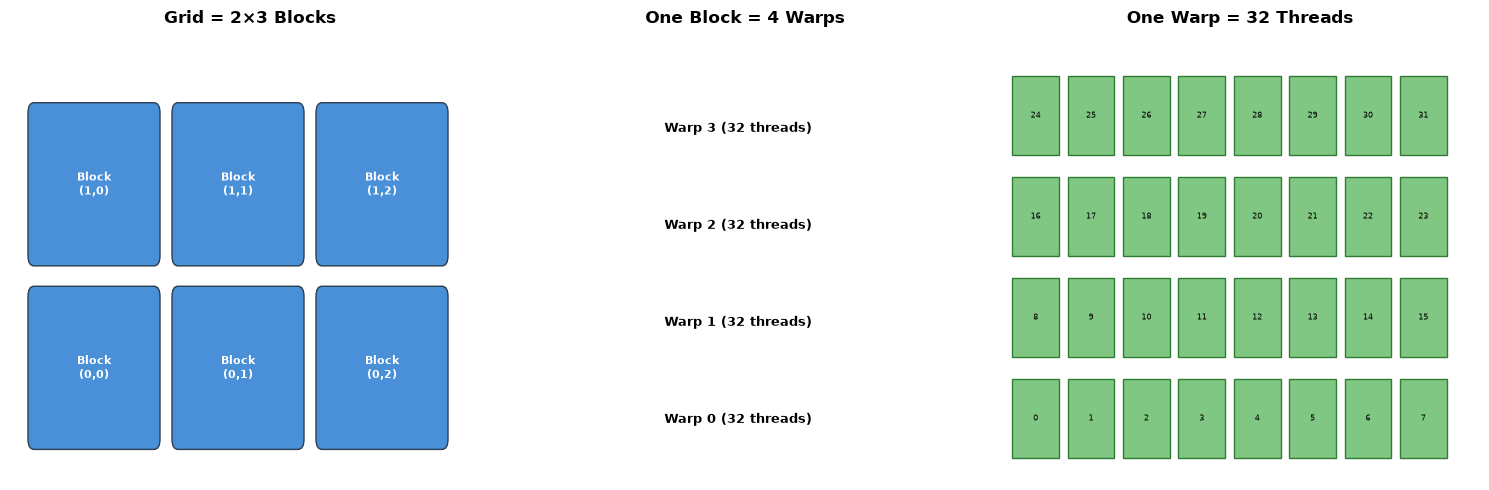

In [3]:

def draw_execution_hierarchy():
    fig, axes = plt.subplots(1, 3, figsize=(15, 5))

    # Grid
    ax = axes[0]
    for r in range(2):
        for c in range(3):
            rect = patches.FancyBboxPatch((c * 1.2, r * 0.9), 1.0, 0.7, boxstyle="round,pad=0.05",
                                          facecolor="#4a90d9", edgecolor="#2c3e50")
            ax.add_patch(rect)
            ax.text(c * 1.2 + 0.5, r * 0.9 + 0.35, "Block" + chr(10) + f"({r},{c})",
                    ha="center", va="center", fontsize=8, color="white", fontweight="bold")
    ax.set_xlim(-0.2, 3.8)
    ax.set_ylim(-0.2, 2.0)
    ax.set_title("Grid = 2×3 Blocks", fontsize=12, fontweight="bold")
    ax.axis("off")

    # Block -> warps
    ax = axes[1]
    for i in range(4):
        rect = patches.FancyBboxPatch((0.2, i * 0.8), 3.0, 0.6, boxstyle="round,pad=0.05",
                                      facecolor="#ffb74d", edgecolor="#2c3e50")
        ax.text(1.7, i * 0.8 + 0.3, f"Warp {i} (32 threads)",
                ha="center", va="center", fontsize=9, fontweight="bold")
    ax.set_xlim(0, 3.5)
    ax.set_ylim(-0.2, 3.5)
    ax.set_title("One Block = 4 Warps", fontsize=12, fontweight="bold")
    ax.axis("off")

    # Warp -> threads
    ax = axes[2]
    for i in range(32):
        c = i % 8
        r = i // 8
        rect = patches.Rectangle((c * 0.45, r * 0.45), 0.38, 0.35,
                                  facecolor="#81c784", edgecolor="#2e7d32")
        ax.add_patch(rect)
        ax.text(c * 0.45 + 0.19, r * 0.45 + 0.175, str(i),
                ha="center", va="center", fontsize=6)
    ax.set_xlim(-0.1, 3.8)
    ax.set_ylim(-0.1, 1.9)
    ax.set_title("One Warp = 32 Threads", fontsize=12, fontweight="bold")
    ax.axis("off")

    plt.tight_layout()
    plt.show()


draw_execution_hierarchy()



### 索引公式

对于 1D grid/block：

```
global_thread_id = blockIdx.x * blockDim.x + threadIdx.x
```

对于 2D：

```
row = blockIdx.y * blockDim.y + threadIdx.y
col = blockIdx.x * blockDim.x + threadIdx.x
```



## Part 4：Warp Scheduler 与 Latency Hiding

当 Warp 0 访问内存时（stall），Warp Scheduler 立即切换到 Warp 1，让 CUDA Cores 不空闲。


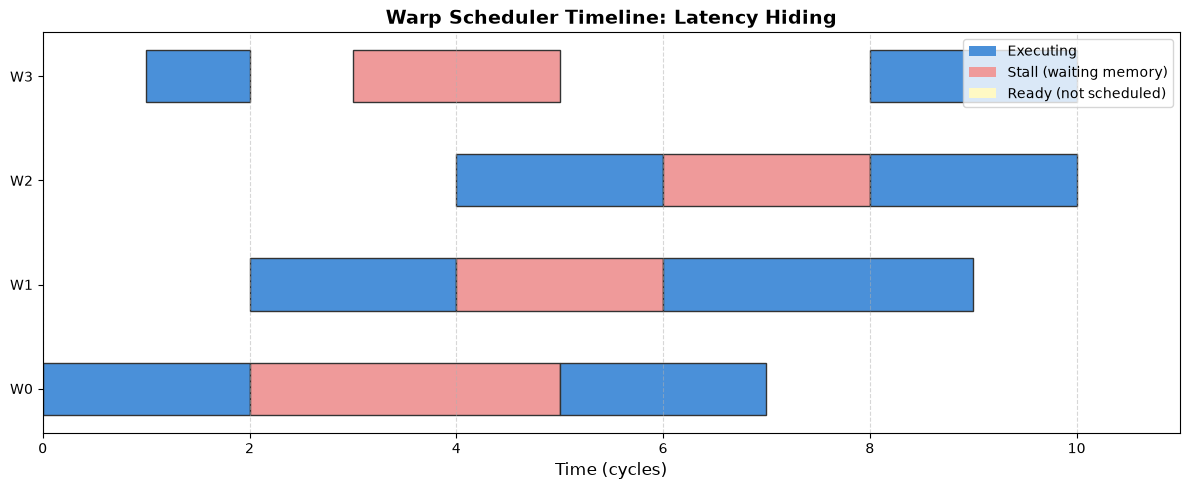

In [4]:

import numpy as np


def draw_warp_scheduler_gantt():
    fig, ax = plt.subplots(figsize=(12, 5))

    warps = ["W0", "W1", "W2", "W3"]
    colors = {"exec": "#4a90d9", "stall": "#ef9a9a", "ready": "#fff9c4"}

    # Timeline data: (start, duration, state)
    schedule = {
        "W0": [(0, 2, "exec"), (2, 3, "stall"), (5, 2, "exec")],
        "W1": [(2, 2, "exec"), (4, 2, "stall"), (6, 3, "exec")],
        "W2": [(4, 2, "exec"), (6, 2, "stall"), (8, 2, "exec")],
        "W3": [(1, 1, "exec"), (3, 2, "stall"), (8, 2, "exec")],
    }

    for i, warp in enumerate(warps):
        for start, duration, state in schedule[warp]:
            ax.barh(i, duration, left=start, color=colors[state], edgecolor="#333", height=0.5)

    ax.set_yticks(range(len(warps)))
    ax.set_yticklabels(warps)
    ax.set_xlabel("Time (cycles)", fontsize=12)
    ax.set_title("Warp Scheduler Timeline: Latency Hiding", fontsize=14, fontweight="bold")

    from matplotlib.patches import Patch
    legend = [Patch(facecolor=colors["exec"], label="Executing"),
              Patch(facecolor=colors["stall"], label="Stall (waiting memory)"),
              Patch(facecolor=colors["ready"], label="Ready (not scheduled)")]
    ax.legend(handles=legend, loc="upper right")
    ax.set_xlim(0, 11)
    ax.grid(axis="x", linestyle="--", alpha=0.5)
    plt.tight_layout()
    plt.show()


draw_warp_scheduler_gantt()



### 解读

- **蓝色条**：warp 正在 CUDA Cores 上执行。
- **红色条**：warp 在等待内存数据，被移出执行。
- 只要 eligible warp 够多，CUDA Cores 几乎不会空闲。
- 这就是 **latency hiding**：用多 warp 并发掩盖内存延迟。



## Part 5：SIMT、Warp Divergence 与 Memory Coalescing

### SIMT
Single Instruction, Multiple Threads：一个 warp 内 32 threads 共享同一个 program counter，执行同一条指令。

### Warp Divergence
如果 warp 内 threads 走不同分支（如 `if (threadIdx.x % 2 == 0)`），硬件会串行执行两个分支，每个分支只激活部分 threads，其他 threads 被 mask 掉。

### Memory Coalescing
一个 warp 内相邻 threads 访问相邻内存地址时，硬件会把这些访问合并成少量 cache line / memory transaction。


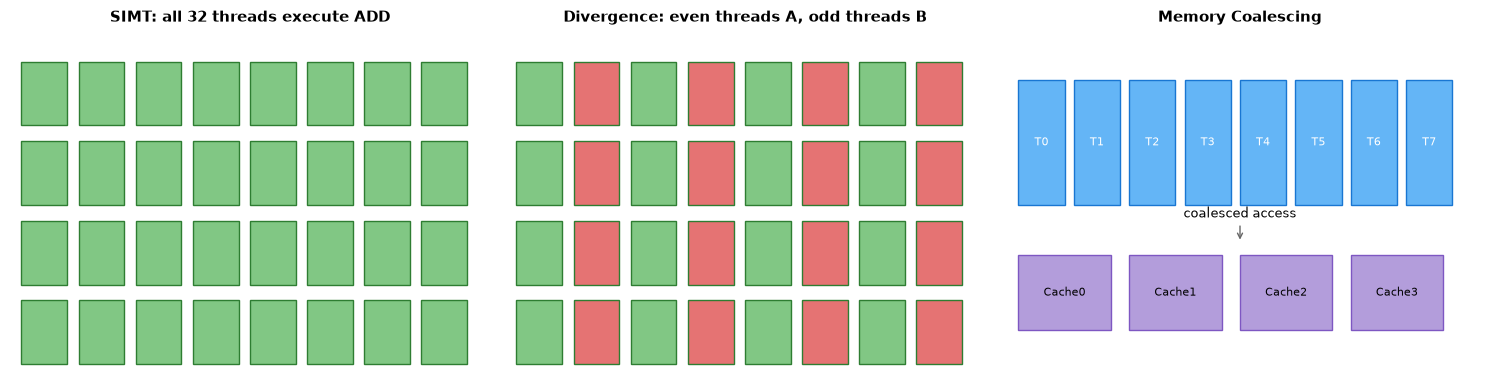

In [5]:

def draw_simt_and_divergence():
    fig, axes = plt.subplots(1, 3, figsize=(15, 4))

    # SIMT: all active
    ax = axes[0]
    for i in range(32):
        c, r = i % 8, i // 8
        ax.add_patch(patches.Rectangle((c * 0.5, r * 0.5), 0.4, 0.4, facecolor="#81c784", edgecolor="#2e7d32"))
    ax.set_title("SIMT: all 32 threads execute ADD", fontsize=11, fontweight="bold")
    ax.set_xlim(-0.1, 4.1)
    ax.set_ylim(-0.1, 2.1)
    ax.axis("off")

    # Divergence
    ax = axes[1]
    for i in range(32):
        c, r = i % 8, i // 8
        color = "#81c784" if i % 2 == 0 else "#e57373"
        ax.add_patch(patches.Rectangle((c * 0.5, r * 0.5), 0.4, 0.4, facecolor=color, edgecolor="#2e7d32"))
    ax.set_title("Divergence: even threads A, odd threads B", fontsize=11, fontweight="bold")
    ax.set_xlim(-0.1, 4.1)
    ax.set_ylim(-0.1, 2.1)
    ax.axis("off")

    # Coalescing
    ax = axes[2]
    for i in range(8):
        ax.add_patch(patches.Rectangle((i * 0.6, 0.5), 0.5, 0.5, facecolor="#64b5f6", edgecolor="#1976d2"))
        ax.text(i * 0.6 + 0.25, 0.75, f"T{i}", ha="center", va="center", fontsize=8, color="white")
    for i in range(4):
        ax.add_patch(patches.Rectangle((i * 1.2, 0), 1.0, 0.3, facecolor="#b39ddb", edgecolor="#7e57c2"))
        ax.text(i * 1.2 + 0.5, 0.15, f"Cache{i}", ha="center", va="center", fontsize=8)
    ax.annotate("coalesced access", xy=(2.4, 0.35), xytext=(2.4, 0.45),
                arrowprops=dict(arrowstyle="->", color="#666"), ha="center", fontsize=9)
    ax.set_title("Memory Coalescing", fontsize=11, fontweight="bold")
    ax.set_xlim(-0.2, 5.0)
    ax.set_ylim(-0.2, 1.2)
    ax.axis("off")

    plt.tight_layout()
    plt.show()


draw_simt_and_divergence()



## Part 6：Occupancy 计算与交互式探索

Occupancy = 每个 SM 上同时活跃的 warp 数 / SM 支持的最大 warp 数。

它受限于：
- 每个 SM 的最大 thread 数
- 每个 SM 的最大 warp 数
- 每个 SM 的寄存器总数
- 每个 SM 的 shared memory 容量


In [6]:

def theoretical_occupancy(
    block_size,
    shared_mem_per_block,
    regs_per_thread,
    max_threads_per_sm=1536,
    max_warps_per_sm=48,
    max_regs_per_sm=65536,
    max_smem_per_sm=49152,
    warp_size=32,
):
    warps_per_block = (block_size + warp_size - 1) // warp_size

    by_threads = max_threads_per_sm // block_size
    by_warps = max_warps_per_sm // warps_per_block
    by_regs = max_regs_per_sm // (regs_per_thread * block_size)
    by_smem = max_smem_per_sm // shared_mem_per_block if shared_mem_per_block > 0 else float("inf")
    max_blocks_per_sm = 32

    blocks_per_sm = min(by_threads, by_warps, by_regs, by_smem, max_blocks_per_sm)
    warps_per_sm = blocks_per_sm * warps_per_block
    occupancy = warps_per_sm / max_warps_per_sm

    limiters = {
        "threads": by_threads,
        "warps": by_warps,
        "registers": by_regs,
        "shared memory": by_smem,
    }
    # 注意：shared memory 为 inf 时不应成为最小值
    actual_limiters = {k: v for k, v in limiters.items() if v != float("inf")}
    limiting_factor = min(actual_limiters, key=actual_limiters.get)

    return {
        "warps_per_block": warps_per_block,
        "blocks_per_sm": blocks_per_sm,
        "warps_per_sm": warps_per_sm,
        "occupancy": occupancy,
        "limiting_factor": limiting_factor,
        "by": {
            "threads": by_threads,
            "warps": by_warps,
            "registers": by_regs,
            "shared_memory": by_smem if shared_mem_per_block > 0 else float("inf"),
        },
    }


# 示例
result = theoretical_occupancy(block_size=128, shared_mem_per_block=0, regs_per_thread=32)
print(f"Warps per block: {result['warps_per_block']}")
print(f"Blocks per SM: {result['blocks_per_sm']}")
print(f"Warps per SM: {result['warps_per_sm']}")
print(f"Occupancy: {result['occupancy']*100:.1f}%")
print(f"Limiting factor: {result['limiting_factor']}")


Warps per block: 4
Blocks per SM: 12
Warps per SM: 48
Occupancy: 100.0%
Limiting factor: threads


In [ ]:

import ipywidgets as widgets
from IPython.display import display, clear_output


block_slider = widgets.IntSlider(value=128, min=32, max=1024, step=32, description="Block size")
smem_slider = widgets.IntSlider(value=0, min=0, max=49152, step=4096, description="Shared mem (B)")
reg_slider = widgets.IntSlider(value=32, min=16, max=128, step=16, description="Regs/thread")
output = widgets.Output()


def on_change(change):
    with output:
        clear_output(wait=True)
        res = theoretical_occupancy(
            block_size=block_slider.value,
            shared_mem_per_block=smem_slider.value,
            regs_per_thread=reg_slider.value,
        )
        print(f"Block size: {block_slider.value}")
        print(f"Shared mem/block: {smem_slider.value} B")
        print(f"Regs/thread: {reg_slider.value}")
        print(f"Warps/block: {res['warps_per_block']}")
        print(f"Blocks/SM: {res['blocks_per_sm']}")
        print(f"Warps/SM: {res['warps_per_sm']}")
        print(f"Occupancy: {res['occupancy']*100:.1f}%")
        print(f"Limiting factor: {res['limiting_factor']}")
        print("-" * 30)
        for k, v in res["by"].items():
            print(f"  limit by {k}: {v:.2f}")


block_slider.observe(on_change, names="value")
smem_slider.observe(on_change, names="value")
reg_slider.observe(on_change, names="value")

on_change(None)
display(widgets.VBox([block_slider, smem_slider, reg_slider, output]))



### 实践建议

1. **优先使用 128 或 256 的 block size**：通常能拿到较高 occupancy。
2. **减少寄存器使用**：编译器选项如 `-maxrregcount` 或 Triton 的 config tuning。
3. **谨慎使用 shared memory**：每 block shared memory 越大，同时驻留的 block 越少。
4. **避免 warp divergence**：让同一 warp 内 threads 走相同分支。
5. **保证 memory coalescing**：相邻 thread 访问相邻地址。



## Part 7：总结与自查清单

### 核心概念

| 概念 | 一句话解释 |
|------|-----------|
| SM | GPU 的计算工厂，包含 scheduler、cores、register、shared memory |
| CUDA Core | 执行单个 thread 指令的标量单元 |
| Grid | Kernel 启动的所有 threads |
| Block | Grid 的子集，内部可协作 |
| Warp | 32 threads 的调度小组 |
| Thread | 单个执行实例 |
| Warp Scheduler | 选择 ready warp 派发指令，实现 latency hiding |
| SIMT | 一个 warp 内 threads 执行同一条指令 |
| Divergence | 同 warp 内 threads 走不同分支，导致串行执行 |
| Coalescing | 相邻 threads 访问相邻地址，合并内存事务 |
| Occupancy | SM 上活跃 warp 比例，越高越能隐藏延迟 |

### 自查清单

- [ ] 能画出 GPU → SM → CUDA Core 的层级结构
- [ ] 能解释 Grid/Block/Warp/Thread 的关系
- [ ] 能写出一个 thread 的全局 ID 公式
- [ ] 能解释 Warp Scheduler 如何通过切换 warp 隐藏延迟
- [ ] 能说明 warp divergence 的危害和避免方法
- [ ] 能解释 memory coalescing 为什么重要
- [ ] 能用 occupancy 公式分析一个 kernel 的瓶颈
